In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
Web_data_1 = pd.read_csv("/Users/levinschily/Desktop/IRONHACK/Week5/project/df_final_web_data_pt_1.txt")
Web_data_2 = pd.read_csv('/Users/levinschily/Desktop/IRONHACK/Week5/project/df_final_web_data_pt_2.txt')
Final_demo = pd.read_csv('/Users/levinschily/Desktop/IRONHACK/Week5/project/df_final_demo.txt')
Clients = pd.read_csv('/Users/levinschily/Desktop/IRONHACK/Week5/project/df_final_experiment_clients.txt')

combined_df = pd.concat([Web_data_1, Web_data_2], ignore_index=True)
combined_df.drop_duplicates()

merged = combined_df.merge(Clients, on='client_id', how='inner')

df = merged.merge(Final_demo, on='client_id', how='inner')
df.drop_duplicates()
df

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449826,9895983,473024645_56027518531,498981662_93503779869_272484,step_3,2017-06-15 19:52:09,NaN,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0
449827,9895983,473024645_56027518531,498981662_93503779869_272484,step_2,2017-06-15 19:50:37,NaN,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0
449828,9895983,473024645_56027518531,498981662_93503779869_272484,step_1,2017-06-15 19:50:05,NaN,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0
449829,9895983,473024645_56027518531,498981662_93503779869_272484,start,2017-06-15 19:50:00,NaN,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0


In [23]:
df["date_time"] = pd.to_datetime(df["date_time"])

df = df.sort_values(by=["Variation", "client_id", "visit_id", "process_step", "date_time"])

df_last_step = df.groupby(["Variation", "client_id", "visit_id", "process_step"]).tail(1)

df_pivot = df_last_step.pivot(index=["Variation", "client_id", "visit_id"], columns="process_step", values="date_time").reset_index()

df_pivot["start_to_step1"] = (df_pivot.get("step_1") - df_pivot.get("start")).dt.total_seconds()
df_pivot["step1_to_step2"] = (df_pivot.get("step_2") - df_pivot.get("step_1")).dt.total_seconds()
df_pivot["step2_to_step3"] = (df_pivot.get("step_3") - df_pivot.get("step_2")).dt.total_seconds()
df_pivot["step3_to_confirm"] = (df_pivot.get("confirm") - df_pivot.get("step_3")).dt.total_seconds()

for col in ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]:
    df_pivot = df_pivot[df_pivot[col] >= 0]

avg_times = df_pivot.groupby("Variation")[["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]].mean().round(2)

print("\n Average time (in seconds) per step by group:")
print(avg_times)


 Average time (in seconds) per step by group:
process_step  start_to_step1  step1_to_step2  step2_to_step3  step3_to_confirm
Variation                                                                     
Control                50.60           49.58           94.69            135.51
Test                   43.55           42.46           93.24            143.01


In [6]:
from scipy.stats import ttest_ind

step_columns = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]

for col in step_columns:
    control_times = df_pivot[df_pivot["Variation"] == "Control"][col].dropna()
    test_times = df_pivot[df_pivot["Variation"] == "Test"][col].dropna()
    
    stat, p_value = ttest_ind(control_times, test_times, equal_var=False) 

    print(f"\nT-test for {col}:")
    print(f"  t-statistic = {stat:.2f}")
    print(f"  p-value     = {p_value:.2f}")
    if p_value < 0.05:
        print("Significant difference at 5% level.")
    else:
        print("No significant difference at 5% level.")


T-test for start_to_step1:
  t-statistic = 5.07
  p-value     = 0.00
Significant difference at 5% level.

T-test for step1_to_step2:
  t-statistic = 7.32
  p-value     = 0.00
Significant difference at 5% level.

T-test for step2_to_step3:
  t-statistic = 1.11
  p-value     = 0.27
No significant difference at 5% level.

T-test for step3_to_confirm:
  t-statistic = -2.26
  p-value     = 0.02
Significant difference at 5% level.


In [8]:
df_merged = df_pivot.merge(
    df[[
        "Variation", "client_id", "visit_id",
        "clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "gendr",
        "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"
    ]],
    on=["Variation", "client_id", "visit_id"],
    how="left"
)

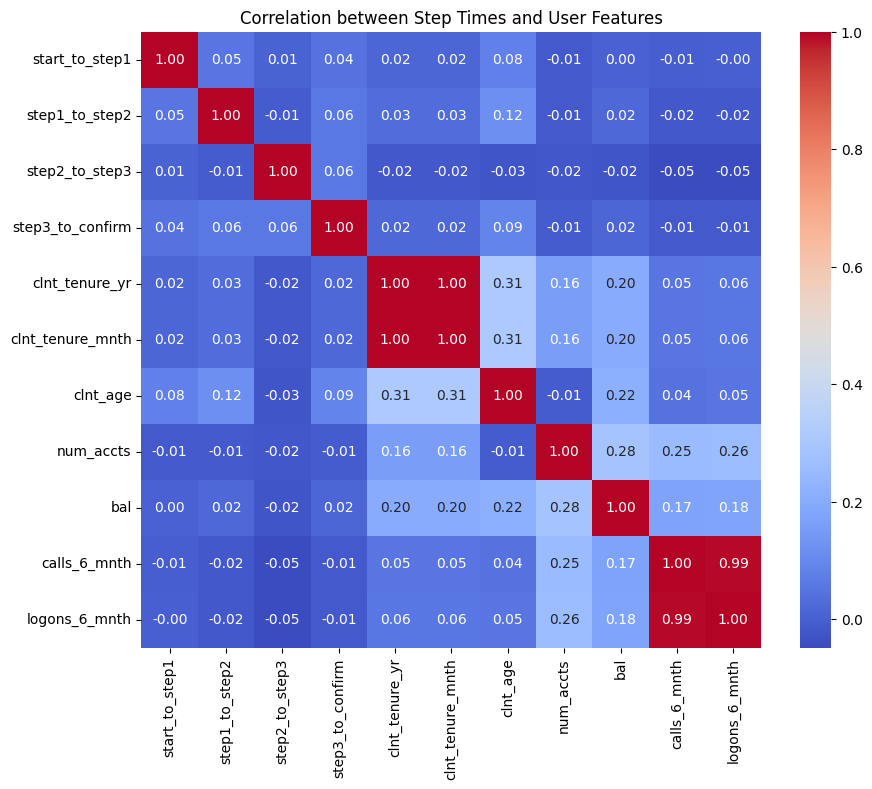

In [12]:
numeric_cols = [
    "start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm",
    "clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "num_accts",
    "bal", "calls_6_mnth", "logons_6_mnth"
]

corr = df_merged[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Step Times and User Features")
plt.show()

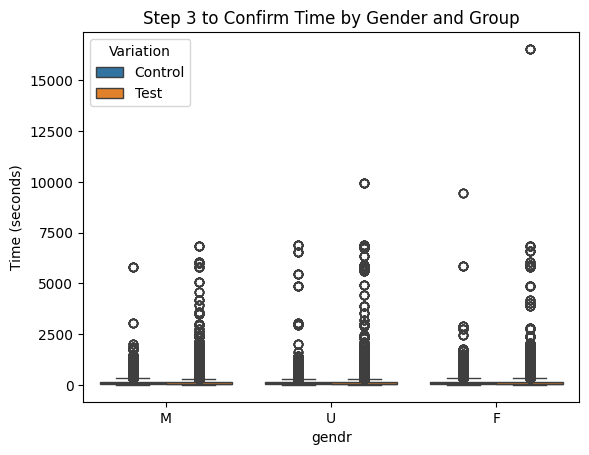

In [14]:
sns.boxplot(data=df_merged, x="gendr", y="step3_to_confirm", hue="Variation")
plt.title("Step 3 to Confirm Time by Gender and Group")
plt.ylabel("Time (seconds)")
plt.show()

In [143]:
avg_times_transposed = avg_times.transpose()

# Export to CSV
avg_times_transposed.to_csv("avg_times_transposed.csv")

print("\nTransposed version saved to 'avg_times_transposed.csv':")
print(avg_times_transposed)


Transposed version saved to 'avg_times_transposed.csv':
Variation         Control    Test
process_step                     
start_to_step1      50.60   43.55
step1_to_step2      49.58   42.46
step2_to_step3      94.69   93.24
step3_to_confirm   135.51  143.01


In [145]:
avg_times_transposed.to_csv("avg_step_times_by_group.csv")

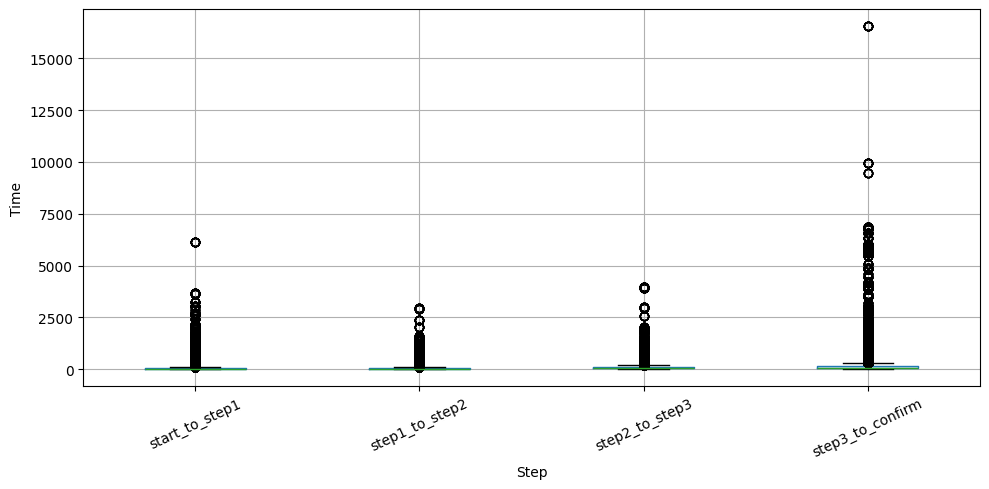

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

step_cols = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]

fig, ax = plt.subplots(figsize=(10,5))
df_full[step_cols].boxplot(ax=ax)
ax.set_ylabel("Time")
ax.set_xlabel("Step")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [41]:
import pandas as pd

step_cols = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]
feature_cols = ["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age",
                "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"]
df_full = df.merge(
    df_pivot[["client_id", "visit_id"] + step_cols],
    on=["client_id", "visit_id"],
    how="left"
)


summary_rows = []

for step in step_cols:
    pct_rank = df_full.groupby("Variation")[step].rank(pct=True)

    low_mask  = pct_rank.le(0.10) & df_full[step].notna()   # bottom 10%
    high_mask = pct_rank.ge(0.90) & df_full[step].notna()   # top 10%

    for side, mask in [("low10%", low_mask), ("high10%", high_mask)]:
        sub = df_full.loc[mask]

        if sub.empty:
            continue

        stats = (sub.groupby("Variation")[feature_cols]
                   .mean()
                   .round(2)
                   .reset_index())

        counts = sub.groupby("Variation").size().rename("N_rows")

        stats = stats.merge(counts, on="Variation")
        stats.insert(0, "OutlierSide", side)
        stats.insert(0, "Step", step)

        summary_rows.append(stats)

summary_df = pd.concat(summary_rows, ignore_index=True)
display(summary_df)

,Step,OutlierSide,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth,N_rows
0,start_to_step1,low10%,Control,11.44,143.24,41.75,2.33,144175.77,3.62,6.64,10933
1,start_to_step1,low10%,Test,11.60,145.25,43.32,2.25,172205.45,3.31,6.34,13471
2,start_to_step1,high10%,Control,12.49,155.93,51.35,2.22,156207.78,3.09,6.14,12791
3,start_to_step1,high10%,Test,12.48,155.92,53.66,2.22,180930.45,3.16,6.22,16193
4,step1_to_step2,low10%,Control,10.17,128.19,39.03,2.21,114234.91,3.40,6.43,12600
5,step1_to_step2,low10%,Test,11.74,146.83,47.65,2.25,176320.19,3.25,6.29,15054
6,step1_to_step2,high10%,Control,12.48,155.77,51.23,2.29,167520.11,3.09,6.14,11902
7,step1_to_step2,high10%,Test,12.64,157.87,53.93,2.24,188692.06,3.20,6.25,15059
8,step2_to_step3,low10%,Control,10.73,134.84,47.29,2.22,151544.74,3.11,6.14,11080
9,step2_to_step3,low10%,Test,12.76,159.14,55.59,2.24,214839.46,3.24,6.29,13545


In [26]:
step_cols = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]

feature_cols = [
    "clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age",
    "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"
]

df_full = df.merge(
    df_pivot[["client_id", "visit_id"] + step_cols],
    on=["client_id", "visit_id"],
    how="left"
)

summary_rows = []

for step in step_cols:
    for feature in feature_cols:
        for variation, group in df_full.groupby("Variation"):
            if step in group.columns and feature in group.columns:
                sub_data = group[[step, feature]].dropna()

                summary_rows.append({
                    "Step": step,
                    "Feature": feature,
                    "Variation": variation,
                    "Mean": round(sub_data[feature].mean(), 2),
                    "Median": round(sub_data[feature].median(), 2)
                })

summary_df = pd.DataFrame(summary_rows)

print("\n Mean & Median of Customer Features by Step and Variation:")
print(summary_df)


 Mean & Median of Customer Features by Step and Variation:
                Step           Feature Variation       Mean    Median
0     start_to_step1    clnt_tenure_yr   Control      11.90     11.00
1     start_to_step1    clnt_tenure_yr      Test      11.88     10.00
2     start_to_step1  clnt_tenure_mnth   Control     148.75    133.00
3     start_to_step1  clnt_tenure_mnth      Test     148.55    131.00
4     start_to_step1          clnt_age   Control      46.86     47.50
5     start_to_step1          clnt_age      Test      46.76     47.50
6     start_to_step1         num_accts   Control       2.27      2.00
7     start_to_step1         num_accts      Test       2.26      2.00
8     start_to_step1               bal   Control  152395.75  65945.70
9     start_to_step1               bal      Test  149837.41  65750.27
10    start_to_step1      calls_6_mnth   Control       3.19      3.00
11    start_to_step1      calls_6_mnth      Test       3.11      3.00
12    start_to_step1     logon

In [48]:
df["date_time"] = pd.to_datetime(df["date_time"])

df = df.sort_values(by=["Variation", "client_id", "visit_id", "process_step", "date_time"])

df_last_step = df.groupby(["Variation", "client_id", "visit_id", "process_step"]).tail(1)

df_pivot = df_last_step.pivot(
    index=["Variation", "client_id", "visit_id"],
    columns="process_step",
    values="date_time"
).reset_index()

df_pivot["start_to_step1"]     = (df_pivot.get("step_1")    - df_pivot.get("start")).dt.total_seconds()
df_pivot["step1_to_step2"]     = (df_pivot.get("step_2")    - df_pivot.get("step_1")).dt.total_seconds()
df_pivot["step2_to_step3"]     = (df_pivot.get("step_3")    - df_pivot.get("step_2")).dt.total_seconds()
df_pivot["step3_to_confirm"]   = (df_pivot.get("confirm")   - df_pivot.get("step_3")).dt.total_seconds()

for col in ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]:
    df_pivot[col + "_was_backwards"] = df_pivot[col] < 0

for col in ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]:
    df_pivot[col] = df_pivot[col].abs()

avg_times = df_pivot.groupby("Variation")[[
    "start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"
]].mean().round(2)

print("\n Average time (in seconds) per step by group (including backtracks):")
print(avg_times)


 Average time (in seconds) per step by group (including backtracks):
process_step  start_to_step1  step1_to_step2  step2_to_step3  step3_to_confirm
Variation                                                                     
Control                80.71           64.02          100.73            135.89
Test                   79.20           58.44          104.20            143.44


In [50]:

step_cols = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]

id_cols = ["Variation", "client_id", "visit_id"]  

long_df = (
    df_full[id_cols + step_cols]
      .melt(id_vars=id_cols, value_vars=step_cols,
            var_name="Step", value_name="Time_seconds")
      .dropna(subset=["Time_seconds"])
)

long_df.to_csv("times_by_step_long.csv", index=False)

In [30]:
from scipy.stats import ttest_ind

step_columns = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]

for col in step_columns:
    control_times = df_pivot[df_pivot["Variation"] == "Control"][col].dropna()
    test_times = df_pivot[df_pivot["Variation"] == "Test"][col].dropna()
    
    stat, p_value = ttest_ind(control_times, test_times, equal_var=False) 

    print(f"\nT-test for {col}:")
    print(f"  t-statistic = {stat:.2f}")
    print(f"  p-value     = {p_value:.2f}")
    if p_value < 0.05:
        print("Significant difference at 5% level.")
    else:
        print("No significant difference at 5% level.")


T-test for start_to_step1:
  t-statistic = 0.64
  p-value     = 0.52
No significant difference at 5% level.

T-test for step1_to_step2:
  t-statistic = 3.24
  p-value     = 0.00
Significant difference at 5% level.

T-test for step2_to_step3:
  t-statistic = -1.95
  p-value     = 0.05
No significant difference at 5% level.

T-test for step3_to_confirm:
  t-statistic = -2.36
  p-value     = 0.02
Significant difference at 5% level.


In [102]:
avg_times_transposed = avg_times.transpose()

# Export to CSV
avg_times_transposed.to_csv("avg_times_transposed2.csv")


In [45]:
df["date_time"] = pd.to_datetime(df["date_time"])

df = df.sort_values(by=["Variation", "client_id", "visit_id", "process_step", "date_time"])

df_last_step = df.groupby(["Variation", "client_id", "visit_id", "process_step"]).tail(1)

df_pivot = df_last_step.pivot(
    index=["Variation", "client_id", "visit_id"],
    columns="process_step",
    values="date_time"
).reset_index()

df_pivot["start_to_step1"]     = (df_pivot.get("step_1")    - df_pivot.get("start")).dt.total_seconds()
df_pivot["step1_to_step2"]     = (df_pivot.get("step_2")    - df_pivot.get("step_1")).dt.total_seconds()
df_pivot["step2_to_step3"]     = (df_pivot.get("step_3")    - df_pivot.get("step_2")).dt.total_seconds()
df_pivot["step3_to_confirm"]   = (df_pivot.get("confirm")   - df_pivot.get("step_3")).dt.total_seconds()

for col in ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]:
    df_pivot[col + "_was_backwards"] = df_pivot[col] < 0

for col in ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]:
    df_pivot[col] = df_pivot[col].abs()

med_times = df_pivot.groupby("Variation")[[
    "start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"
]].median().round(2)

print("\n Average time (in seconds) per step by group (including backtracks):")
print(med_times)


med_times = med_times.transpose()
med_times.to_csv("med_times.csv")


 Average time (in seconds) per step by group (including backtracks):
process_step  start_to_step1  step1_to_step2  step2_to_step3  step3_to_confirm
Variation                                                                     
Control                 21.0            23.0            68.0              77.0
Test                    13.0            24.0            68.0              59.0


In [34]:
from scipy.stats import median_test
import pandas as pd

step_columns = ["start_to_step1", "step1_to_step2", "step2_to_step3", "step3_to_confirm"]
alpha = 0.05

rows = []
for col in step_columns:
    c = df_pivot.loc[df_pivot["Variation"] == "Control", col].dropna()
    t = df_pivot.loc[df_pivot["Variation"] == "Test",    col].dropna()

    chi2, p, grand_med, table = median_test(c, t)
    sig = "SIGNIFICANT" if p < alpha else "not significant"

    print(f"\nMedian test for {col}:")
    print(f"  Control median = {c.median():.2f}")
    print(f"  Test median    = {t.median():.2f}")
    print(f"  Grand median   = {grand_med:.2f}")
    print(f"  chi2 = {chi2:.2f}, p = {p:.4f}  -> {sig} at α={alpha}")

    rows.append({
        "Step": col,
        "median_Control": c.median(),
        "median_Test": t.median(),
        "diff_median": c.median() - t.median(),
        "grand_median": grand_med,
        "chi2": chi2,
        "p_value": p,
        "Significant_@0.05": p < alpha,
        "N_control": len(c),
        "N_test": len(t)
    })

results_med = pd.DataFrame(rows).round(3)
print("\nSummary table:")
print(results_med)


Median test for start_to_step1:
  Control median = 21.00
  Test median    = 13.00
  Grand median   = 16.00
  chi2 = 995.87, p = 0.0000  -> SIGNIFICANT at α=0.05

Median test for step1_to_step2:
  Control median = 23.00
  Test median    = 24.00
  Grand median   = 24.00
  chi2 = 4.33, p = 0.0375  -> SIGNIFICANT at α=0.05

Median test for step2_to_step3:
  Control median = 68.00
  Test median    = 68.00
  Grand median   = 68.00
  chi2 = 0.34, p = 0.5601  -> not significant at α=0.05

Median test for step3_to_confirm:
  Control median = 77.00
  Test median    = 59.00
  Grand median   = 68.00
  chi2 = 439.19, p = 0.0000  -> SIGNIFICANT at α=0.05

Summary table:
               Step  median_Control  median_Test  diff_median  grand_median  \
0    start_to_step1            21.0         13.0          8.0          16.0   
1    step1_to_step2            23.0         24.0         -1.0          24.0   
2    step2_to_step3            68.0         68.0          0.0          68.0   
3  step3_to_confir

In [157]:
summary_df.to_csv("top_bottom_10%_characteristics.csv")